In [3]:
# for mathematical operations
import numpy as np
import pandas as pd
import matplotlib
# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
# to transform a png to an array
from matplotlib.image import imread
# to interact with the operating system (Kaggle data in our case)
import os

In [4]:
# empty lists to store image paths
par_img_path = [] 
uninf_img_path = []

for image_path in os.listdir('C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Parasitized/'): # loop through all image names in 'Parasitized' folder
    par_img_path.append('C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Parasitized/' + image_path) # create the path for the particular image
    
for image_path in os.listdir('C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Uninfected/'): # loop through all image names in 'Uninfected' folder
    uninf_img_path.append('C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\Uninfected/' + image_path) # create the path for the particular image
    
cell_type_par = len(par_img_path) * ['parasitized'] # create a list with all values as 'parasitized' with the length of list being the length of par_img_path
cell_type_uninf = len(uninf_img_path) * ['uninfected'] # create a list with all values as 'uninfected' with the length of list being the length of uninf_img_path

# create a dataframe with a column containing parasitized images' path and another column with the label from cell_type_par
df_par = pd.DataFrame({'image_path': par_img_path, 'cell_type': cell_type_par}) 
# create a dataframe with a column containing uninfected images' path and another column with the label from cell_type_uninf
df_uninf = pd.DataFrame({'image_path': uninf_img_path, 'cell_type': cell_type_uninf})

df = pd.concat([df_par, df_uninf]) # concat both the dataframes along rows to get the final dataframe

df = df.reset_index(drop=True) # reset index to be from 0 to length of dataframe. drop=True drops the initial index, which otherwise is added as a new column
df

,image_path,cell_type
0,C:\Users\jains16\Desktop\ML Project\archive\ce...,parasitized
1,C:\Users\jains16\Desktop\ML Project\archive\ce...,parasitized
2,C:\Users\jains16\Desktop\ML Project\archive\ce...,parasitized
3,C:\Users\jains16\Desktop\ML Project\archive\ce...,parasitized
4,C:\Users\jains16\Desktop\ML Project\archive\ce...,parasitized
...,...,...
27555,C:\Users\jains16\Desktop\ML Project\archive\ce...,uninfected
27556,C:\Users\jains16\Desktop\ML Project\archive\ce...,uninfected
27557,C:\Users\jains16\Desktop\ML Project\archive\ce...,uninfected
27558,C:\Users\jains16\Desktop\ML Project\archive\ce...,uninfected


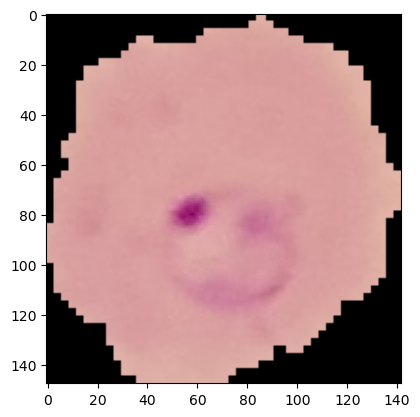

In [5]:
plt.imshow(imread(df['image_path'][0]));


In [6]:
from sklearn.model_selection import train_test_split 

In [7]:
train_par, test_par = train_test_split(df[df['cell_type'] == 'parasitized'],test_size=0.15) # test set is 15% of available data

In [8]:
train_par.shape

(11713, 2)

In [9]:
test_par.shape

(2067, 2)

In [10]:
train_uninf, test_uninf = train_test_split(df[df['cell_type'] == 'uninfected'],test_size=0.15) # test set is 15% of available data

In [11]:
train_uninf.shape

(11713, 2)

In [12]:
test_uninf.shape

(2067, 2)

In [13]:
df_train = pd.concat([train_par, train_uninf])
df_test = pd.concat([test_par, test_uninf])

In [14]:
df_train.shape

(23426, 2)

In [15]:
df_test.shape

(4134, 2)

In [16]:
# empty lists to store length and width of images
dim1 = []
dim2 = []

for image_filename in df_test['image_path']:
    if image_filename[-3:] == 'png': # to eliminate encountering Thumbs.db (Thumbs.db is nothing but the image cache file)
        img = imread(image_filename)
        d1,d2,colors = img.shape #(image.shape is in the form (130, 130, 3))
        dim1.append(d1)
        dim2.append(d2)

In [17]:
# sns.jointplot(x=dim1,y=dim2, color='#88D9B1');

In [18]:
np.mean(dim1)

132.78229317851958

In [19]:
np.mean(dim2)

132.2365747460087

In [20]:
image_shape = (132,132,3) # the 3 represents the number of channels (r, g, b)

In [21]:
from keras.layers import Dense, Flatten
from keras.models import Model
from keras.models import Sequential

In [22]:
from sklearn.metrics import classification_report,confusion_matrix

In [23]:
from keras.applications.vgg16 import VGG16

In [24]:
vgg = VGG16(input_shape=image_shape, weights='imagenet', include_top=False); # we set our model's name as vgg

In [25]:
for layer in vgg.layers:
  layer.trainable = False

In [26]:
from tensorflow.keras.layers import GlobalAveragePooling2D

In [25]:
# not required
# refer https://keras.io/guides/functional_api/ AND https://keras.io/api/applications/ (also given at the top of the notebook)
x = vgg.output
x = GlobalAveragePooling2D()(x) # layer not compulsory to add
x = Dense(1024, activation='relu')(x) # layer not compulsory to add

# a dense laye with 1 neuron as the output because our dataset is binary, i.e., an image can either be parasitized or uninfected
# use activation as sigmoid for binary classification datasets
predictions = Dense(1, activation='sigmoid')(x)

# Specify inputs and outputs to create final model
vgg_model = Model(inputs=vgg.input, outputs=predictions) 

vgg_model.compile(loss='binary_crossentropy', # use binary_crossentropy as our data is binary
              optimizer='adam', # other optimizers can be tried
              metrics=['accuracy'])

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [28]:
train_datagen = ImageDataGenerator(rescale = 1/255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1/255)

In [29]:
# generate batches for training 
training_set =  train_datagen.flow_from_dataframe(dataframe = df_train, 
                                                  x_col='image_path', # column in `dataframe` that contains the filenames
                                                  y_col='cell_type', # column in `dataframe` that has the target data
                                                  class_mode='binary', # because oyr dataset is binary
                                                  target_size=(132,132), # target image size (length, width)
                                                  batch_size=32); # add batch size

# generate batches for testing 
test_set = test_datagen.flow_from_dataframe(dataframe = df_test, 
                                            x_col='image_path', 
                                            y_col='cell_type', 
                                            class_mode='binary', 
                                            target_size=(132,132), 
                                            shuffle=False, 
                                            batch_size=32);

Found 23424 validated image filenames belonging to 2 classes.


C:\Users\jains16\AppData\Local\anaconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


Found 4134 validated image filenames belonging to 2 classes.


In [30]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=2)

In [30]:
# not required
results = vgg_model.fit(training_set,
                    epochs=20,
                    validation_data=test_set, # on which data should the model validate on
                    callbacks=[early_stop]); # set early stopping

Epoch 1/20


C:\Users\jains16\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


732/732 ━━━━━━━━━━━━━━━━━━━━ 584s 795ms/step - accuracy: 0.8501 - loss: 0.3404 - val_accuracy: 0.9311 - val_loss: 0.1920
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 573s 781ms/step - accuracy: 0.9207 - loss: 0.2090 - val_accuracy: 0.8940 - val_loss: 0.2593
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 558s 761ms/step - accuracy: 0.9266 - loss: 0.1978 - val_accuracy: 0.9357 - val_loss: 0.1766
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 504s 687ms/step - accuracy: 0.9305 - loss: 0.1864 - val_accuracy: 0.9081 - val_loss: 0.2347
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 519s 708ms/step - accuracy: 0.9312 - loss: 0.1860 - val_accuracy: 0.9364 - val_loss: 0.1753
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 620s 846ms/step - accuracy: 0.9330 - loss: 0.1773 - val_accuracy: 0.9395 - val_loss: 0.1643
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 1169s 2s/step - accuracy: 0.9340 - loss: 0.1782 - val_accuracy: 0.9221 - val_loss: 0.2187
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 1134s 2s/step - accuracy: 0.9312 - loss: 0.1825 -

In [31]:
# not required
losses = pd.DataFrame(vgg_model.history.history) 

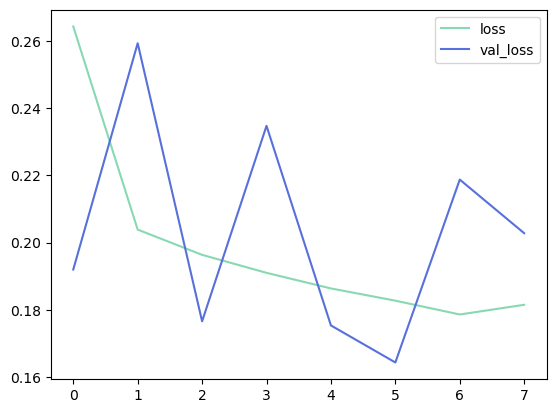

In [32]:
# not required
losses[['loss','val_loss']].plot(color=['#88D9B1', '#5770DB']);


In [33]:
# not required
pred_probabilities = vgg_model.predict(test_set) # returns probabilities of an image being parasitized or uninfected
predictions = pred_probabilities > 0.5 # boolean predictions on test data, whether the model thinks an image is parasitized or uninfected

130/130 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step


In [34]:
# not required
print(classification_report(test_set.classes,predictions)) 

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2067
           1       0.89      0.98      0.93      2067

    accuracy                           0.93      4134
   macro avg       0.93      0.93      0.92      4134
weighted avg       0.93      0.93      0.92      4134



In [35]:
# not required
training_set.class_indices 

{'parasitized': 0, 'uninfected': 1}

In [36]:
# not required
predictions

array([[ True],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [ True]])

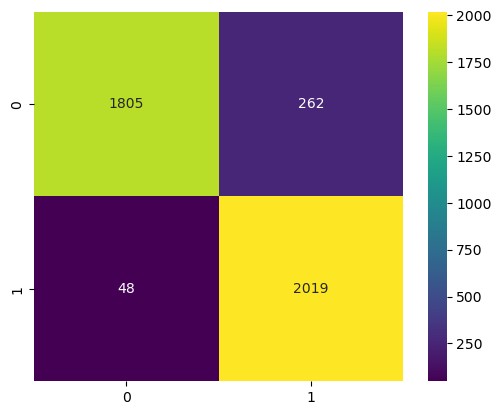

In [37]:
# not required
#plot_confusion_matrix does not work directly for neural networks
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(df_test['cell_type'].map({'parasitized': 0, 'uninfected': 1}),predictions) # df_test has string labels. we need to convert it into boolean values
f = sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', square=True) # create a heatmap of confusion_matrix

In [38]:
# not required
vgg_model_accuracy = losses['val_accuracy'].iloc[-1].round(2) * 100
vgg_model_accuracy

93.0

In [39]:
# not required
vgg_model.save('vgg_malaria.h5')

In [31]:
from keras.applications.inception_v3 import InceptionV3

In [32]:
inception = InceptionV3(input_shape=image_shape, weights='imagenet', include_top=False)

In [33]:
for layer in inception.layers:
  layer.trainable = False

In [34]:
x = inception.output
x = GlobalAveragePooling2D()(x) 
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

inception_model = Model(inputs=inception.input, outputs=predictions) 

inception_model.compile(loss='binary_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

In [35]:
results = inception_model.fit(training_set,epochs=20,
                              validation_data=test_set,
                              callbacks=[early_stop])

Epoch 1/20


C:\Users\jains16\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


732/732 ━━━━━━━━━━━━━━━━━━━━ 161s 210ms/step - accuracy: 0.8344 - loss: 0.6679 - val_accuracy: 0.8861 - val_loss: 0.2803
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 159s 216ms/step - accuracy: 0.8901 - loss: 0.2733 - val_accuracy: 0.8989 - val_loss: 0.2511
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 158s 214ms/step - accuracy: 0.8965 - loss: 0.2563 - val_accuracy: 0.9006 - val_loss: 0.2486
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 155s 211ms/step - accuracy: 0.9001 - loss: 0.2461 - val_accuracy: 0.9064 - val_loss: 0.2434
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 156s 212ms/step - accuracy: 0.9019 - loss: 0.2440 - val_accuracy: 0.9047 - val_loss: 0.2458
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 155s 211ms/step - accuracy: 0.9035 - loss: 0.2416 - val_accuracy: 0.9054 - val_loss: 0.2425
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 153s 208ms/step - accuracy: 0.9059 - loss: 0.2392 - val_accuracy: 0.9054 - val_loss: 0.2351
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 155s 211ms/step - accuracy: 0.9028 - loss: 0.23

In [36]:
losses = pd.DataFrame(inception_model.history.history)

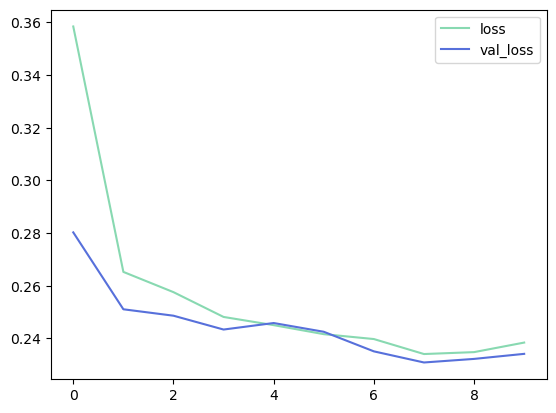

In [37]:
losses[['loss','val_loss']].plot(color=['#88D9B1', '#5770DB']);

130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step
              precision    recall  f1-score   support

           0       0.94      0.88      0.90      2067
           1       0.88      0.94      0.91      2067

    accuracy                           0.91      4134
   macro avg       0.91      0.91      0.91      4134
weighted avg       0.91      0.91      0.91      4134



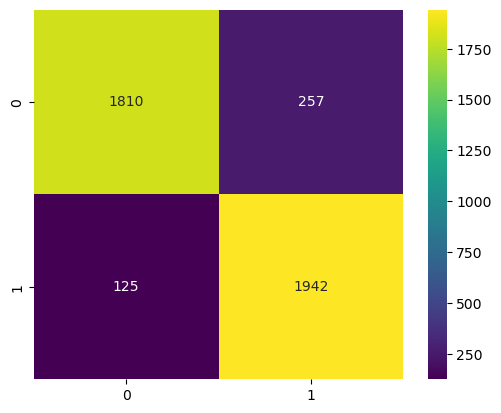

In [38]:
pred_probabilities = inception_model.predict(test_set)
predictions = pred_probabilities > 0.5

print(classification_report(test_set.classes,predictions))


from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(df_test['cell_type'].map({'parasitized': 0, 'uninfected': 1}),predictions)
f = sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', square=True)

In [39]:
inception_model_accuracy = losses['val_accuracy'].iloc[-1].round(2) * 100
inception_model_accuracy

91.0

In [40]:
inception_model.save('inception_malaria.h5')